# LSTM Model for Crisis Future Prediction Up To the Next 3Months

In [2]:
!pip install --upgrade pip
!pip install -r requirements.txt

  Using cached pip-24.3.1-py3-none-any.whl.metadata (3.7 kB)
Using cached pip-24.3.1-py3-none-any.whl (1.8 MB)
  Attempting uninstall: pip
    Found existing installation: pip 23.3.2
    Uninstalling pip-23.3.2:
      Successfully uninstalled pip-23.3.2
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached catboost-1.2.7-cp311-cp311-manylinux2014_x86_64.whl.metadata (1.2 kB)
  Using cached lightgbm-4.5.0-py3-none-manylinux_2_28_x86_64.whl.metadata (17 kB)
  Using cached tensorflow-2.18.0-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (4.1 kB)
  Using cached keras-3.6.0-py3-none-any.whl.metadata (5.8 kB)
  Using cached xgboost-2.1.2-py3-none-manylinux_2_28_x86_64.whl.metadata (2.1 kB)
  Using cached optuna-4.1.0-py3-none-any.whl.metadata (16 kB)
  Using cached shap-0.46.0-cp311-cp311-manylinux_2_12_x86_64.manylinux2010_x86_64.manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (24 kB)
  Using cached torch-2.5.1-cp311-cp311-manylinux1_x8

# 1. Initialize Configuration & Import custom modules

In [2]:
# Set up Python path
import sys
from pathlib import Path
project_root = Path.cwd().parent
sys.path.append(str(project_root))

# Standard libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import GridSearchCV, ParameterGrid

# Custom modules
from scripts.config import Config
from scripts.data_loader import DataLoader
from scripts.preprocessing import DataPreprocessor
from scripts.feature_engineering import FeatureEngineering
from scripts.feature_importance import FeatureSelector
from scripts.model_architecture import CrisisPredictor
from scripts.training import ModelTrainer
from scripts.evaluation import ModelEvaluator
from scripts.uncertainty import UncertaintyEstimator
from scripts.visualization import Visualizer
from scripts.model_persistence import ModelPersistence

# Initialize configuration
config = Config()
print("Configuration loaded successfully")

2024-11-16 08:04:47.036188: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1731744287.056169     191 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1731744287.062364     191 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-11-16 08:04:47.082781: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Configuration loaded successfully


# 2. Load and Prepare Data

In [3]:
import importlib
import scripts.data_loader
importlib.reload(scripts.data_loader)
from scripts.data_loader import DataLoader

# Create new instances
config = Config()
data_loader = DataLoader(config=config)

# Debug prints
print("DataLoader instance:", data_loader)
print("DataLoader __dict__:", data_loader.__dict__)

Initializing DataLoader with config: <scripts.config.Config object at 0x7ff6102751d0>
Config stored in DataLoader: <scripts.config.Config object at 0x7ff6102751d0>
DataLoader instance: <scripts.data_loader.DataLoader object at 0x7ff674089f90>
DataLoader __dict__: {'_config': <scripts.config.Config object at 0x7ff6102751d0>}


In [4]:
data_loader = DataLoader(config)
df = data_loader.load_data()
train_df, test_df = data_loader.split_temporal(df)
print(f"Training set size: {len(train_df)}, Test set size: {len(test_df)}")

Initializing DataLoader with config: <scripts.config.Config object at 0x7ff6102751d0>
Config stored in DataLoader: <scripts.config.Config object at 0x7ff6102751d0>
Loading data from: /root/ACAPS/src/task-3-modelling/scripts/Combined_Dataset_Experimentation/combined_data.csv


/root/ACAPS/src/task-3-modelling/scripts/data_loader.py:25: DtypeWarning: Columns (25,26,27,28,30,31,33,34,35,56,61,64,69,72,229,232,237,240,245,248,253,256,261,264,269,272,277,280,285,288,292,297,299,302,303,304,322,323,331,332,333,334,338,346,347,348,349,350,351,378) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(data_path)


Training set size: 10799, Test set size: 2463


# Data Split Analysis

- From data_loader.py, we're using temporal splitting
- Config specifies test_size = 0.2 (20% of most recent data for testing)
- The split is temporal, meaning earlier data for training, later data for testing

## Train/Test Split
- Training data: Earlier months up to split_date
- Test data: Most recent months after split_date

In [5]:
# Visualize train/test split
print("Training Data Period:")
print(f"Start: {train_df['YYYY_MM'].min()}")
print(f"End: {train_df['YYYY_MM'].max()}")
print("\nTesting Data Period:")
print(f"Start: {test_df['YYYY_MM'].min()}")
print(f"End: {test_df['YYYY_MM'].max()}")

# Optional: Display sample counts by month
print("\nMonthly Distribution:")
print("\nTraining Data:")
print(train_df['YYYY_MM'].value_counts().sort_index().head())
print("...")
print(train_df['YYYY_MM'].value_counts().sort_index().tail())
print("\nTesting Data:")
print(test_df['YYYY_MM'].value_counts().sort_index())


Training Data Period:
Start: 2020_09
End: 2023_12

Testing Data Period:
Start: 2024_01
End: 2024_09

Monthly Distribution:

Training Data:
YYYY_MM
2020_09    270
2020_10    303
2020_11    327
2020_12    286
2021_01    277
Name: count, dtype: int64
...
YYYY_MM
2023_08    272
2023_09    276
2023_10    281
2023_11    276
2023_12    278
Name: count, dtype: int64

Testing Data:
YYYY_MM
2024_01    275
2024_02    272
2024_03    268
2024_04    268
2024_05    266
2024_06    267
2024_07    268
2024_08    281
2024_09    298
Name: count, dtype: int64


## 2.1 Data Visualization and Analysis (Experimental)

In [6]:
# Check the structure of targets in config
print("Target specifications:", config.targets)

# Check the actual columns in train_df
print("\nAvailable columns in training data:", train_df.columns.tolist())

# Check a sample of the target variables
for target, specs in config.targets.items():
    print(f"\nTarget: {target}")
    print(f"Columns: {specs['columns']}")
    print("Sample data:")
    print(train_df[specs['columns']].head())

Target specifications: {'severity_level': {'columns': ['Inform Severity Index', 'Inform Severity Category'], 'type': 'regression'}, 'crisis_probability': {'columns': ['Concentration Of Conditions', 'Complexity Of The Crisis', 'Updated_Score'], 'type': 'multiclass'}, 'escalation_risk': {'columns': ['Trend (Last 3 Months)', 'Impact Of The Crisis'], 'type': 'multiclass'}}

Available columns in training data: ['YYYY_MM', 'Crisis Id', 'Crisis', 'Country', 'Iso3', 'Empowerment', 'Bti - Democracy Status', 'Trust In Society', 'Ethnic Fractionalisation', 'Size Of Excluded Ethnic Groups', 'Gender Inequality', 'Income Gini Coefficient', 'Inequality', 'Social Cohesion', 'Conflict Intensity', 'Total Killed In All Crisis', 'Safety And Security', 'Corruption Perception', 'Rule Of Law (Wgi)', 'Rule Of Law (Bti)', 'Freedom In The World', 'Rule Of Law', 'Society And Safety', '# Of Different Types Of Affected Population Groups', 'Diversity Of Groups Affected', 'Impediments To Entry Into Country (Bureaucr

In [7]:
# Check data types for each target
for target, specs in config.targets.items():
    print(f"\nTarget: {target}")
    for col in specs['columns']:
        print(f"\nColumn: {col}")
        print("Data type:", train_df[col].dtype)
        print("Sample values:", train_df[col].head())
        print("Number of unique values:", train_df[col].nunique())
        print("Sample of unique values:", train_df[col].unique()[:5])  # Show first 5 unique values
        print("Value counts:\n", train_df[col].value_counts().head())  # Show top 5 most common values with their counts
        print("-" * 50)


Target: severity_level

Column: Inform Severity Index
Data type: object
Sample values: 0    4.6
1    3.3
2    3.9
3    2.4
4    NaN
Name: Inform Severity Index, dtype: object
Number of unique values: 42
Sample of unique values: ['4.6' '3.3' '3.9' '2.4' nan]
Value counts:
 Inform Severity Index
x      483
3.5    250
3.4    246
2.3    219
3.2    208
Name: count, dtype: int64
--------------------------------------------------

Column: Inform Severity Category
Data type: object
Sample values: 0      5
1      4
2      4
3      3
4    NaN
Name: Inform Severity Category, dtype: object
Number of unique values: 6
Sample of unique values: ['5' '4' '3' nan '2']
Value counts:
 Inform Severity Category
4    1792
3    1745
5     739
2     617
x     483
Name: count, dtype: int64
--------------------------------------------------

Target: crisis_probability

Column: Concentration Of Conditions
Data type: object
Sample values: 0    4
1    3
2    5
3    1
4    2
Name: Concentration Of Conditions, dtype

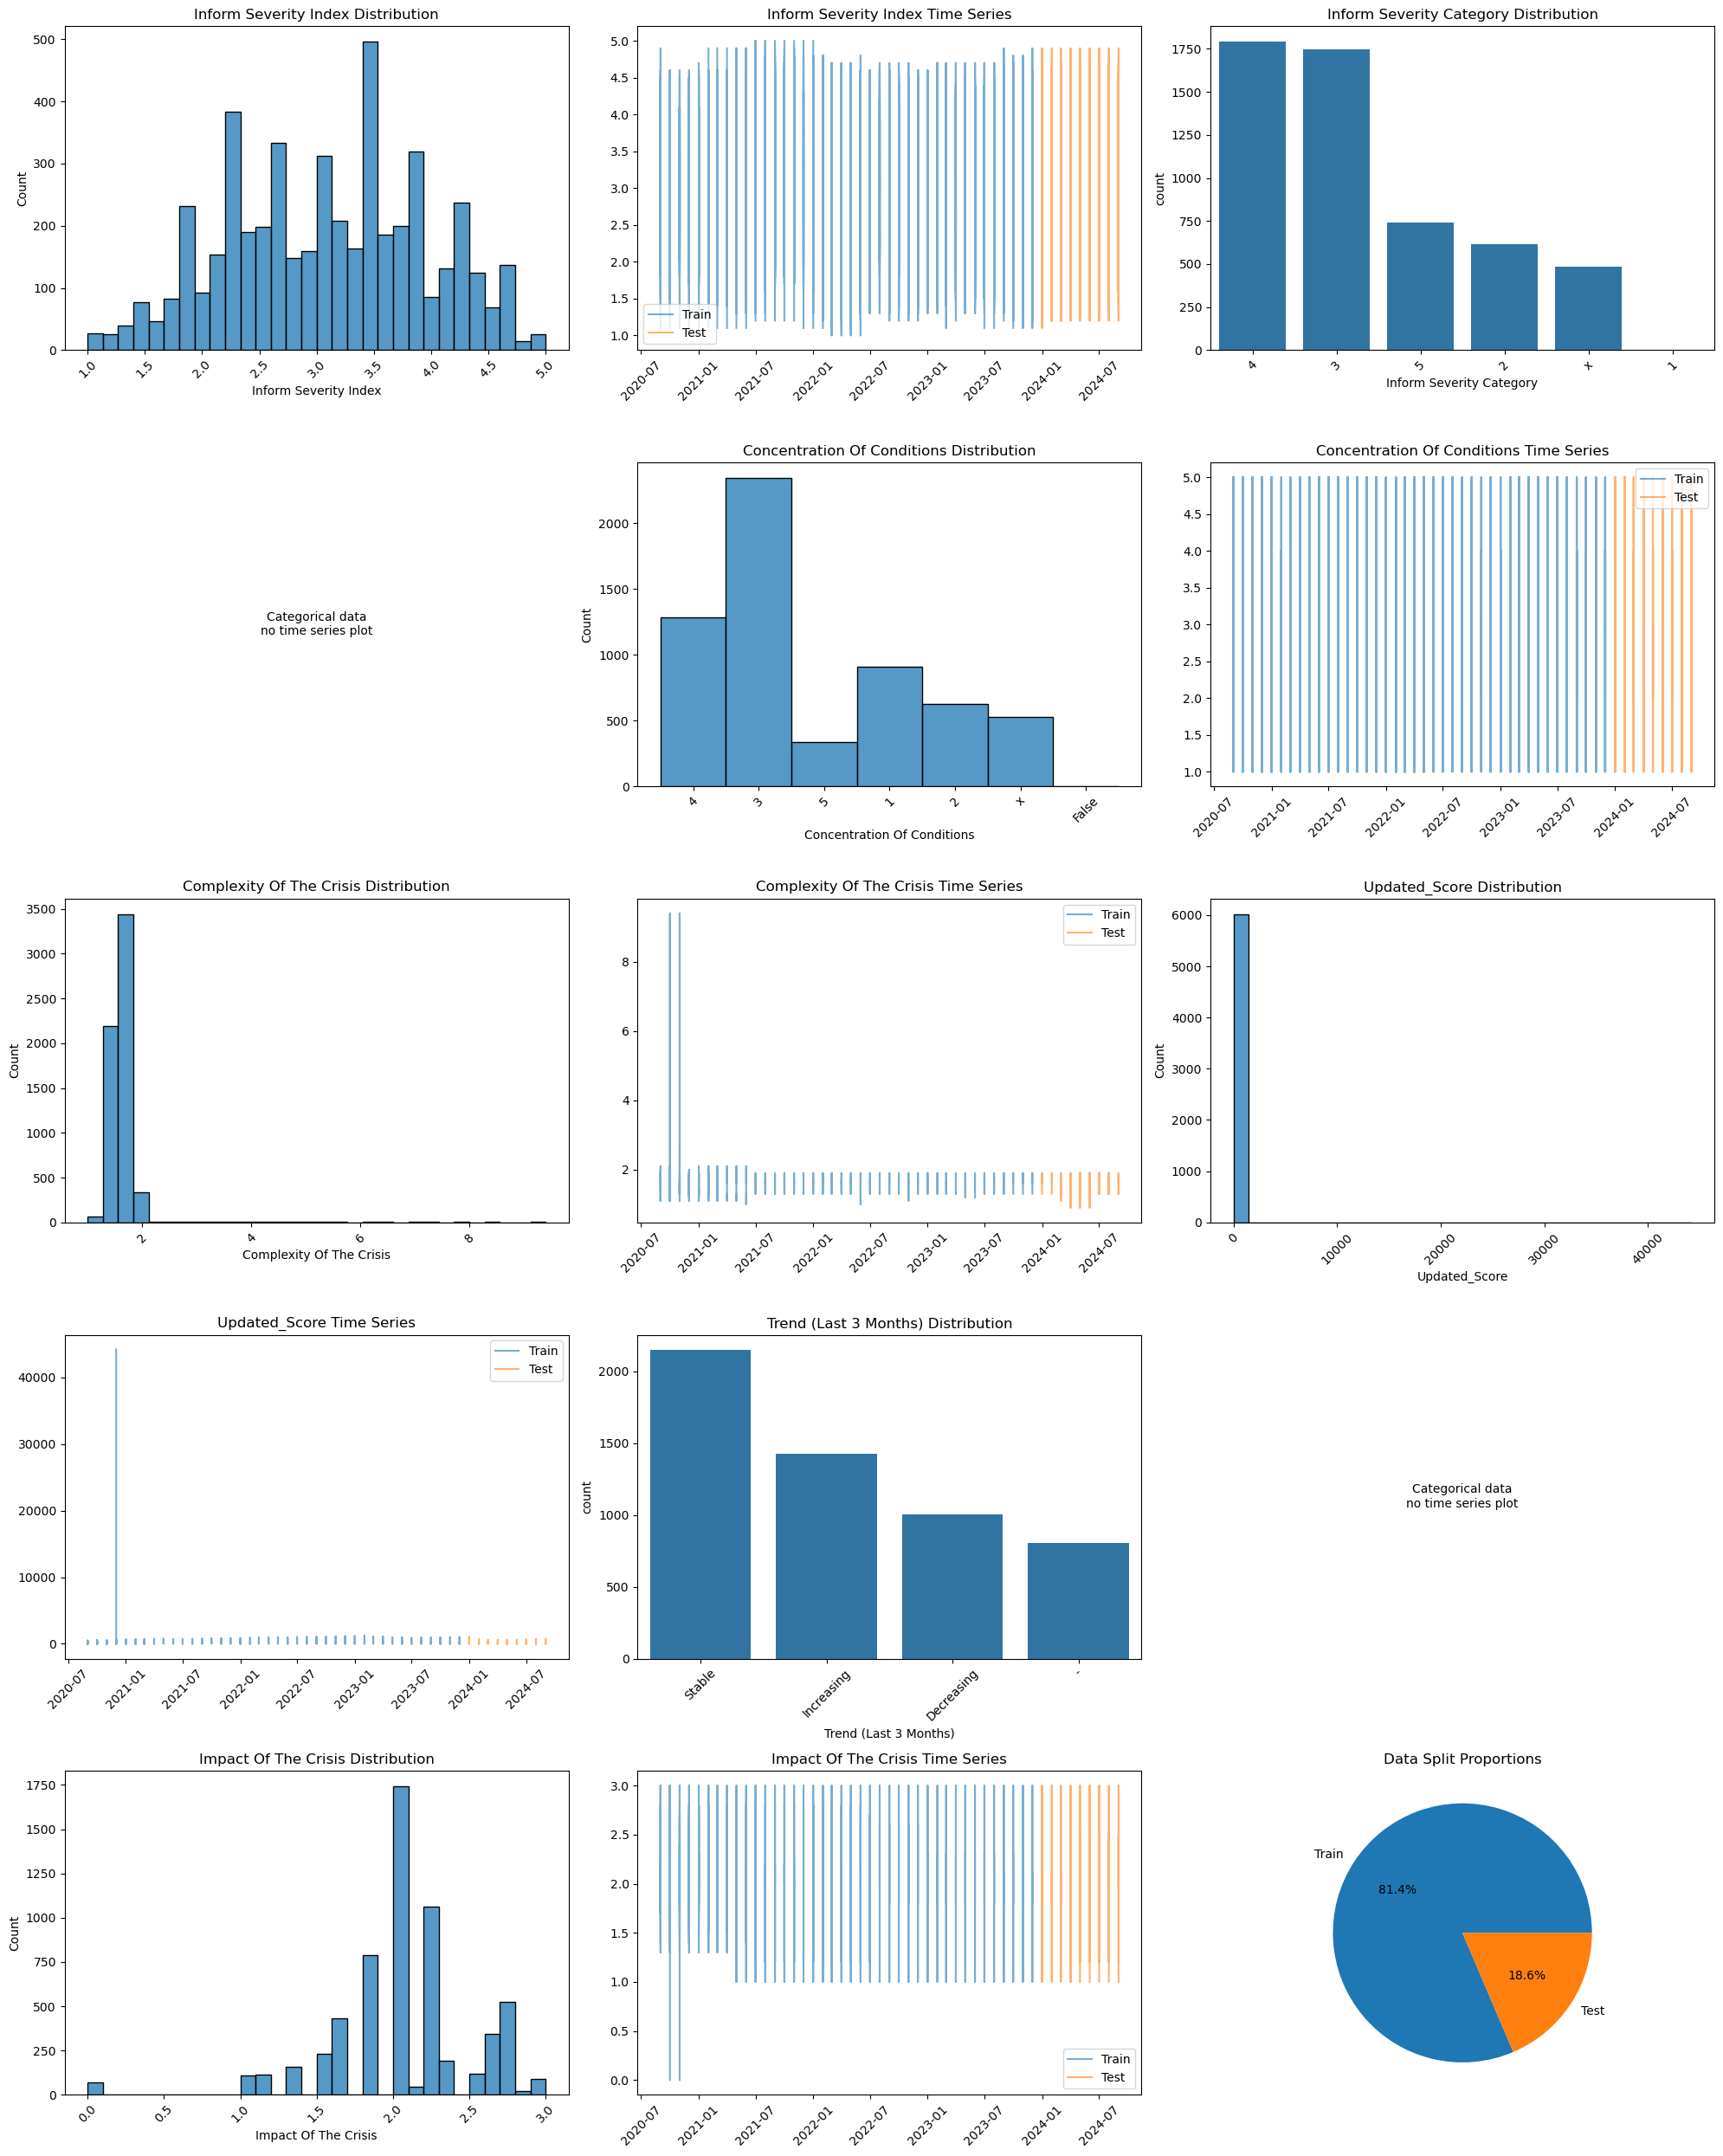


Data Distribution Statistics:
--------------------------------------------------
Total samples: 13262
Training samples: 10799 (81.4%)
Testing samples: 2463 (18.6%)

Target Variable Statistics:
--------------------------------------------------

Target: severity_level

Column: Inform Severity Index
Value counts:
 Inform Severity Index
3.5    250
3.4    246
2.3    219
3.2    208
3.7    200
Name: count, dtype: int64
Null values: 5902

Column: Inform Severity Category
Value counts:
 Inform Severity Category
4    1792
3    1745
5     739
2     617
x     483
Name: count, dtype: int64
Null values: 5419

Target: crisis_probability

Column: Concentration Of Conditions
Value counts:
 Concentration Of Conditions
3    2345
4    1282
1     907
2     628
x     527
Name: count, dtype: int64
Null values: 4775

Column: Complexity Of The Crisis
Value counts:
 Complexity Of The Crisis
1.6    2236
1.3    1278
1.7    1176
1.4     675
1.9     317
Name: count, dtype: int64
Null values: 4703

Column: Updated

In [8]:
def visualize_batch_data(train_df, test_df, config):
    train_df = train_df.copy()
    test_df = test_df.copy()
    
    total_plots = sum(len(specs['columns']) * 2 for _, specs in config.targets.items()) + 1
    rows = (total_plots + 2) // 3
    cols = 3
    
    plt.figure(figsize=(20, 5*rows))
    subplot_idx = 1
    
    for target, specs in config.targets.items():
        for col in specs['columns']:
            # Convert string numbers to float where applicable
            if col in ['Inform Severity Index', 'Impact Of The Crisis']:
                train_df.loc[:, col] = pd.to_numeric(train_df[col], errors='coerce')
                test_df.loc[:, col] = pd.to_numeric(test_df[col], errors='coerce')
            
            # Distribution plot
            plt.subplot(rows, cols, subplot_idx)
            if col in ['Trend (Last 3 Months)', 'Inform Severity Category']:
                # Categorical plots
                sns.countplot(data=train_df, x=col, order=train_df[col].value_counts().index)
                plt.xticks(rotation=45)
            else:
                # Numerical plots
                sns.histplot(train_df[col].dropna(), bins=30)
            plt.title(f'{col} Distribution')
            plt.xticks(rotation=45)
            subplot_idx += 1
            
            # Time series plot
            plt.subplot(rows, cols, subplot_idx)
            if col in ['Trend (Last 3 Months)', 'Inform Severity Category']:
                # Skip time series for categorical data
                plt.text(0.5, 0.5, 'Categorical data\nno time series plot', 
                        ha='center', va='center')
                plt.axis('off')
            else:
                # Convert to numeric for time series plot
                train_values = pd.to_numeric(train_df[col], errors='coerce')
                test_values = pd.to_numeric(test_df[col], errors='coerce')
                plt.plot(train_df['date'], train_values, label='Train', alpha=0.6)
                plt.plot(test_df['date'], test_values, label='Test', alpha=0.6)
                plt.title(f'{col} Time Series')
                plt.legend()
                plt.xticks(rotation=45)
            subplot_idx += 1
    
    # Data split proportions
    plt.subplot(rows, cols, subplot_idx)
    splits = [len(train_df), len(test_df)]
    plt.pie(splits, labels=['Train', 'Test'], autopct='%1.1f%%')
    plt.title('Data Split Proportions')
    
    plt.tight_layout()
    plt.show()
    
    # Print statistics
    print("\nData Distribution Statistics:")
    print("-" * 50)
    print(f"Total samples: {len(df)}")
    print(f"Training samples: {len(train_df)} ({len(train_df)/len(df)*100:.1f}%)")
    print(f"Testing samples: {len(test_df)} ({len(test_df)/len(df)*100:.1f}%)")
    
    print("\nTarget Variable Statistics:")
    print("-" * 50)
    for target, specs in config.targets.items():
        print(f"\nTarget: {target}")
        for col in specs['columns']:
            print(f"\nColumn: {col}")
            print("Value counts:\n", train_df[col].value_counts().head())
            print("Null values:", train_df[col].isnull().sum())

# Call the function
visualize_batch_data(train_df, test_df, config)

# 3. Feature Engineering and Selection
This section is divided into four parts:
1. Diagnostic code to check all feature & target groups
2. Analyzing column characteristics
3. Feature Engineering
4. Total No. of Features after Feature Engineering
5. Feature Selection & Importance (will be calculated soon!)

## 3.1 Diagnostic code to check all feature & target groups

In [11]:
# Diagnostic code that checks all feature groups in the config
def analyze_data_quality(df, config):
    print("\nComprehensive Data Quality Analysis:")
    print("-" * 50)
    
    for group_name, features in config.feature_groups.items():
        print(f"\nFeature Group: {group_name}")
        print("-" * 30)
        
        for col in features:
            print(f"\nColumn: {col}")
            print("Data type:", df[col].dtype)
            # Check for non-numeric values
            non_numeric = df[col][~df[col].astype(str).str.replace('.', '').str.isnumeric()]
            print("Non-numeric values found:", non_numeric.unique())
            print("Count of non-numeric values:", len(non_numeric))
            # Show value distribution
            print("Value distribution:")
            print(df[col].value_counts().head())
            print("-" * 20)

# Run the analysis
analyze_data_quality(train_df, config)


Comprehensive Data Quality Analysis:
--------------------------------------------------

Feature Group: temporal_context
------------------------------

Column: YYYY_MM
Data type: object
Non-numeric values found: ['2020_09' '2020_10' '2020_11' '2020_12' '2021_01' '2021_02' '2021_03'
 '2021_04' '2021_05' '2021_06' '2021_07' '2021_08' '2021_09' '2021_10'
 '2021_11' '2021_12' '2022_01' '2022_02' '2022_03' '2022_04' '2022_05'
 '2022_06' '2022_07' '2022_08' '2022_09' '2022_10' '2022_11' '2022_12'
 '2023_01' '2023_02' '2023_03' '2023_04' '2023_05' '2023_06' '2023_07'
 '2023_08' '2023_09' '2023_10' '2023_11' '2023_12']
Count of non-numeric values: 10799
Value distribution:
YYYY_MM
2020_11    327
2020_10    303
2020_12    286
2023_10    281
2023_12    278
Name: count, dtype: int64
--------------------

Column: Country
Data type: object
Non-numeric values found: ['Afghanistan' 'Burundi' 'Burkina Faso' 'Bangladesh' 'Brazil' 'CAR'
 'China' 'Cameroon' 'DRC' 'Congo' 'Colombia' 'Costa Rica' 'Djibou

## 3.2 Analyzing column characteristics

In [12]:
def analyze_column_characteristics(df, config):
    print("\nColumn Characteristics Analysis:")
    print("-" * 50)
    
    for group_name, features in config.feature_groups.items():
        print(f"\nFeature Group: {group_name}")
        print("-" * 30)
        
        for col in features:
            print(f"\nColumn: {col}")
            print("Current data type:", df[col].dtype)
            
            # Check for NaN values
            has_nan = df[col].isna().any()
            print("Contains NaN values:", has_nan)
            if has_nan:
                print("Number of NaN values:", df[col].isna().sum())
            
            # For numerical columns, show stats
            if df[col].dtype in ['float64', 'int64']:
                print("Statistical summary:")
                print(df[col].describe())
            else:
                unique_values = df[col].unique()[:5]
                print("Sample distinct values:", unique_values)
                
                special_chars = df[col].astype(str).str.contains('[^a-zA-Z0-9\s]').any()
                if special_chars:
                    print("Contains special characters: Yes")
            
            # Refined recommendations
            if col == 'YYYY_MM':
                print("Recommended: Convert to datetime for time series analysis")
            elif col in ['Country', 'Iso3', 'Region', 'Crisis Id', 'Crisis']:
                print("Recommended: Keep as categorical identifier")
            elif 'Date' in col:
                print("Recommended: Convert to datetime")
            elif df[col].dtype in ['float64', 'int64']:
                print("Recommended: Already numerical, handle missing values")
            elif df[col].dtype == 'object' and df[col].str.contains('x').any():
                print("Recommended: Replace 'x' with 0, convert to float")
            else:
                print("Recommended: Evaluate for categorical encoding")
                
            print("-" * 20)

# Run the analysis
analyze_column_characteristics(train_df, config)


Column Characteristics Analysis:
--------------------------------------------------

Feature Group: temporal_context
------------------------------

Column: YYYY_MM
Current data type: object
Contains NaN values: False
Sample distinct values: ['2020_09' '2020_10' '2020_11' '2020_12' '2021_01']
Contains special characters: Yes
Recommended: Convert to datetime for time series analysis
--------------------

Column: Country
Current data type: object
Contains NaN values: True
Number of NaN values: 116
Sample distinct values: ['Afghanistan' 'Burundi' 'Burkina Faso' 'Bangladesh' 'Brazil']
Contains special characters: Yes
Recommended: Keep as categorical identifier
--------------------

Column: Iso3
Current data type: object
Contains NaN values: True
Number of NaN values: 4775
Sample distinct values: ['Afg' 'Bdi' 'Bfa' 'Bgd' 'Bra']
Contains special characters: Yes
Recommended: Keep as categorical identifier
--------------------

Column: Region
Current data type: object
Contains NaN values: Tru

## 3.3 Feature Engineering

In [13]:
from scripts.feature_engineering import FeatureEngineering
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer
import pandas as pd
import numpy as np
import re

def clean_feature_names(X):
    X = X.copy()
    def clean_name(name):
        name = str(name)
        name = re.sub(r'[^A-Za-z0-9]+', '_', name)
        name = re.sub(r'_{2,}', '_', name)
        name = name.strip('_')
        if not name[0].isalpha():
            name = 'f_' + name
        return name
    
    clean_columns = [clean_name(col) for col in X.columns]
    X.columns = clean_columns
    return X

class CustomFeatureEngineering(FeatureEngineering):
    def __init__(self, config):
        super().__init__(config)
        self.label_encoders = {}
        self.null_values = ['x', 'X', 'Missing', 'missing', 'False', 'false', '-', 'NA', 'na', 'N/A', 'n/a']
        self.categorical_cols = ['Country', 'Iso3', 'Region', 'Crisis Id', 'Crisis']
        self.identifier_cols = []
        self.date_formats = {
            'standard': '%Y-%m-%d',
            'datetime': '%Y-%m-%d %H:%M:%S',
            'year_month': '%Y_%m'
        }
        
    def process_features(self, df: pd.DataFrame):
        self.identifier_cols = [col for col in df.columns if any(x in col for x in ['Total population', 'Helper'])]
        df = df.copy()
        processed_df = df.copy()
        
        # Process each feature group
        for group_name, features in self.config.feature_groups.items():
            processed_df = self._process_feature_group(processed_df, features, group_name)
            
        # Create derived features
        temporal_features = self._create_temporal_features(processed_df)
        encoded_features = self._encode_categorical_features(temporal_features)
        
        # Additional feature derivation
        final_features = self._derive_additional_features(encoded_features)
        
        return {
            'base': processed_df,
            'temporal': temporal_features,
            'encoded': encoded_features,
            'final': final_features
        }
    
    def _process_feature_group(self, df, features, group_name):
        df = df.copy()
        
        for col in features:
            if col not in df.columns:
                continue
                
            if col in self.categorical_cols or col in self.identifier_cols:
                continue
            elif 'Date' in col:
                df[col] = self._parse_dates(df[col])
            elif col == 'YYYY_MM':
                df[col] = pd.to_datetime(df[col], format=self.date_formats['year_month'])
            else:
                df[col] = self._convert_numeric(df[col])
                
        return df
    
    def _parse_dates(self, series):
        for format_name, date_format in self.date_formats.items():
            try:
                return pd.to_datetime(series, format=date_format)
            except:
                continue
        return pd.to_datetime(series, errors='coerce')
    
    def _convert_numeric(self, series):
        return pd.to_numeric(series.replace(self.null_values, 0), errors='coerce').fillna(0)
    
    def _create_temporal_features(self, df):
        df = df.copy()
        df['datetime'] = pd.to_datetime(df['YYYY_MM'], format=self.date_formats['year_month'])
        
        # Extract temporal components
        df['year'] = df['datetime'].dt.year
        df['month'] = df['datetime'].dt.month
        df['quarter'] = df['datetime'].dt.quarter
        df['year_month'] = df['datetime'].dt.strftime('%Y%m')
        df['month_of_quarter'] = df['month'] % 3 + 1
        
        return df
    
    def _encode_categorical_features(self, df):
        df = df.copy()
        categorical_cols = [col for col in self.categorical_cols if col in df.columns]
        
        for col in categorical_cols:
            if col not in self.label_encoders:
                self.label_encoders[col] = LabelEncoder()
            df[f'{col}_encoded'] = self.label_encoders[col].fit_transform(df[col].astype(str))
            
        return df
    
    def _derive_additional_features(self, df):
        df = df.copy()
        
        # Add any domain-specific feature combinations here
        numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
        
        # Calculate rolling statistics for numeric columns
        for col in numeric_cols:
            df[f'{col}_rolling_mean'] = df.groupby('Crisis Id')[col].transform(
                lambda x: x.rolling(window=3, min_periods=1).mean()
            )
            
        return df

class CustomDataPreprocessor:
    def __init__(self, config):
        self.config = config
        self.numerical_imputer = SimpleImputer(strategy='constant', fill_value=0)
        self.categorical_imputer = SimpleImputer(strategy='constant', fill_value='missing')

    def process_data(self, data_dict):
        processed = {}
        for key, df in data_dict.items():
            if isinstance(df, pd.DataFrame):
                processed[key] = self.handle_missing_values(df)
        return processed

    def handle_missing_values(self, df):
        df = df.copy()
        
        # Handle numerical columns
        numerical_cols = df.select_dtypes(include=['float64', 'int64']).columns
        if len(numerical_cols) > 0:
            df[numerical_cols] = self.numerical_imputer.fit_transform(df[numerical_cols])
            
        # Handle categorical columns
        categorical_cols = df.select_dtypes(include=['object']).columns
        if len(categorical_cols) > 0:
            df[categorical_cols] = self.categorical_imputer.fit_transform(df[categorical_cols])
            
        return df

def process_features(df, config):
    feature_engineer = CustomFeatureEngineering(config)
    preprocessor = CustomDataPreprocessor(config)
    
    engineered_features = feature_engineer.process_features(df)
    processed_data = preprocessor.process_data(engineered_features)
    
    return processed_data

def detailed_inspection(processed_data):
    print("\nDetailed Data Processing Results:")
    print("-" * 50)
    
    for key, df in processed_data.items():
        print(f"\nDataset Type: {key}")
        print(f"Shape: {df.shape}")
        
        print("\nFeature Types Summary:")
        print(df.dtypes.value_counts())
        
        print("\nNumerical Columns Statistics:")
        numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
        if len(numeric_cols) > 0:
            print(df[numeric_cols].describe())
        
        print("\nMissing Values Summary:")
        missing_vals = df.isnull().sum()
        if missing_vals.any():
            print(missing_vals[missing_vals > 0])
        else:
            print("No missing values found")
        
        print("-" * 50)

# Run processing and inspection
train_processed = process_features(train_df, config)
detailed_inspection(train_processed)


Detailed Data Processing Results:
--------------------------------------------------

Dataset Type: base
Shape: (10799, 399)

Feature Types Summary:
object            317
float64            78
datetime64[ns]      4
Name: count, dtype: int64

Numerical Columns Statistics:
        Empowerment  Bti - Democracy Status  Trust In Society  \
count  10799.000000            10799.000000      10799.000000   
mean       1.506528                1.436874          1.499643   
std        1.627075                1.456608          1.511796   
min        0.000000                0.000000          0.000000   
25%        0.000000                0.000000          0.000000   
50%        1.100000                1.400000          1.500000   
75%        2.900000                2.800000          2.800000   
max        5.000000                4.300000          4.450000   

       Ethnic Fractionalisation  Size Of Excluded Ethnic Groups  \
count              10799.000000                    10799.000000   
mean   

## 3.4 Total No. of Features after Feature Engineering

In [14]:
def display_feature_count(df):
    print("Feature Count Breakdown:")
    print("-" * 50)
    
    # Base features
    base_features = set()
    for features in config.feature_groups.values():
        base_features.update(features)
    print(f"Base unique features: {len(base_features)}")
    
    # Engineered features
    temporal_features = ['year', 'month', 'quarter', 'month_sin', 'month_cos']
    geographical_features = ['region_encoded', 'country_encoded']
    composite_indices = [
        'socio_economic_index', 'inequality_index',
        'governance_index', 'rule_of_law_composite',
        'crisis_severity_index', 'economic_impact_ratio',
        'humanitarian_severity_index', 'displacement_ratio',
        'access_constraint_index', 'physical_security_constraint'
    ]
    
    # Lag features (3 lags for each important indicator)
    lag_features = len(['crisis_severity_index', 'humanitarian_severity_index', 'access_constraint_index']) * 3
    
    print(f"Temporal features: {len(temporal_features)}")
    print(f"Geographical features: {len(geographical_features)}")
    print(f"Composite indices: {len(composite_indices)}")
    print(f"Lag features: {lag_features}")
    
    # One-hot encoded features
    categorical_columns = ['Country', 'Region', 'Crisis']
    onehot_features = sum([len(df[col].unique()) for col in categorical_columns])
    print(f"One-hot encoded features: {onehot_features}")
    
    total_features = len(df.columns)
    print(f"\nTotal features in model input: {total_features}")

# Run this after feature engineering cell
display_feature_count(train_processed['final'])

Feature Count Breakdown:
--------------------------------------------------
Base unique features: 44
Temporal features: 5
Geographical features: 2
Composite indices: 10
Lag features: 9
One-hot encoded features: 533

Total features in model input: 493


# 4. Model Training

## 4.1 LSTM Model Training

Starting data preparation...

Data shapes:
Features shape: torch.Size([10767, 30, 166])
Target shape: torch.Size([10767, 3, 2])
LSTM Model Features:
--------------------------------------------------
Input tensor shape: torch.Size([10767, 30, 166])

Number of features used: 166

Features:
1. YYYY_MM
2. Crisis Id
3. Crisis
4. Country
5. Iso3
6. Empowerment
7. Bti - Democracy Status
8. Trust In Society
9. Ethnic Fractionalisation
10. Size Of Excluded Ethnic Groups
11. Gender Inequality
12. Income Gini Coefficient
13. Inequality
14. Social Cohesion
15. Conflict Intensity
16. Total Killed In All Crisis
17. Safety And Security
18. Corruption Perception
19. Rule Of Law (Wgi)
20. Rule Of Law (Bti)
21. Freedom In The World
22. Rule Of Law
23. Society And Safety
24. # Of Different Types Of Affected Population Groups
25. Diversity Of Groups Affected
26. Impediments To Entry Into Country (Bureaucratic And Administrative)
27. Restriction Of Movement (Impediments To Freedom Of Movement And/Or Admin

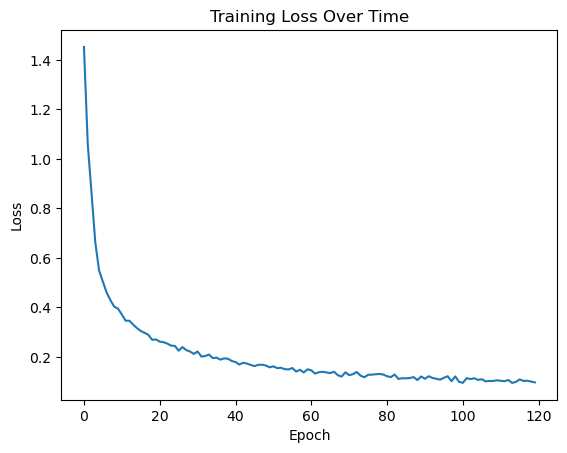

In [16]:
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder, StandardScaler

class LSTMPredictor(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, forecast_horizon=3, n_layers=2, dropout=0.2):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.n_layers = n_layers
        self.forecast_horizon = forecast_horizon

        self.lstm = nn.LSTM(input_dim, hidden_dim, n_layers, batch_first=True, dropout=dropout)
        self.fc = nn.Linear(hidden_dim, output_dim * forecast_horizon)

    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        predictions = self.fc(lstm_out[:, -1, :])
        return predictions.view(-1, self.forecast_horizon, predictions.shape[-1] // self.forecast_horizon)

def prepare_training_data(processed_data, sequence_length=30, forecast_horizon=3):
    df = processed_data['final'].copy()
    null_values = ['x', 'X', 'Missing', 'missing', 'False', 'false', '-', 'NA', 'na', 'N/A', 'n/a']

    # Prepare features
    numeric_features = df.select_dtypes(include=['float64', 'int64']).columns
    X = df[numeric_features].fillna(0).values

    # Standardize features
    scaler = StandardScaler()
    X = scaler.fit_transform(X)

    # Prepare target columns
    target_cols = config.targets['severity_level']['columns']
    y = df[target_cols].copy()
    for col in target_cols:
        y[col] = pd.to_numeric(y[col].replace(null_values, '0'), errors='coerce')
    y = y.values

    # Create sequences for input and 3-month targets
    sequences = []
    targets = []
    for i in range(len(X) - sequence_length - forecast_horizon + 1):
        sequences.append(X[i:(i + sequence_length)])
        targets.append(y[i + sequence_length:i + sequence_length + forecast_horizon])

    X_sequences = np.array(sequences, dtype=np.float32)
    y_sequences = np.array(targets, dtype=np.float32)

    return torch.FloatTensor(X_sequences), torch.FloatTensor(y_sequences), scaler

def show_lstm_features(X_train):
    print("LSTM Model Features:")
    print("-" * 50)
    print(f"Input tensor shape: {X_train.shape}")
    
    # Get feature names from processed data
    feature_names = train_processed['final'].columns.tolist()
    selected_features = feature_names[:X_train.shape[2]]
    
    print(f"\nNumber of features used: {len(selected_features)}")
    print("\nFeatures:")
    for i, feature in enumerate(selected_features, 1):
        print(f"{i}. {feature}")

def train_model(X_train, y_train, config):
    input_dim = X_train.shape[2]
    hidden_dim = config.model_params['lstm']['units']
    output_dim = y_train.shape[2]
    forecast_horizon = 3

    model = LSTMPredictor(
        input_dim=input_dim,
        hidden_dim=hidden_dim,
        output_dim=output_dim,
        forecast_horizon=forecast_horizon,
        dropout=config.model_params['lstm']['dropout']
    )

    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=config.model_params['learning_rate'])
    n_epochs = config.model_params['lstm']['epochs']
    batch_size = config.model_params['lstm']['batch_size']
    grad_clip = 1.0  # Set default gradient clipping value

    train_losses = []
    for epoch in range(n_epochs):
        model.train()
        total_loss = 0
        n_batches = len(X_train) // batch_size

        for i in range(n_batches):
            start_idx = i * batch_size
            end_idx = start_idx + batch_size

            batch_X = X_train[start_idx:end_idx]
            batch_y = y_train[start_idx:end_idx]

            optimizer.zero_grad()
            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)

            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
            optimizer.step()

            total_loss += loss.item()

        avg_loss = total_loss / n_batches
        train_losses.append(avg_loss)

        if (epoch + 1) % 10 == 0:
            print(f'Epoch [{epoch+1}/{n_epochs}], Loss: {avg_loss:.4f}')

    return model, train_losses

# Training execution
print("Starting data preparation...")
X_train, y_train, scaler = prepare_training_data(train_processed)

print("\nData shapes:")
print(f"Features shape: {X_train.shape}")
print(f"Target shape: {y_train.shape}")
show_lstm_features(X_train)

print("\nStarting model training...")
trained_model, history = train_model(X_train, y_train, config)

print("\nTraining completed successfully!")

# Plot training loss
import matplotlib.pyplot as plt
plt.plot(history)
plt.title('Training Loss Over Time')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.show()

# 5. Model Evaluation & Visualization

Generating predictions for evaluation...

Model Performance Metrics:
--------------------------------------------------

MONTH_1:
MSE: 0.0414
RMSE: 0.2035
MAE: 0.0810
R2: 0.9845

MONTH_2:
MSE: 0.0492
RMSE: 0.2219
MAE: 0.0838
R2: 0.9816

MONTH_3:
MSE: 0.0681
RMSE: 0.2610
MAE: 0.1054
R2: 0.9745


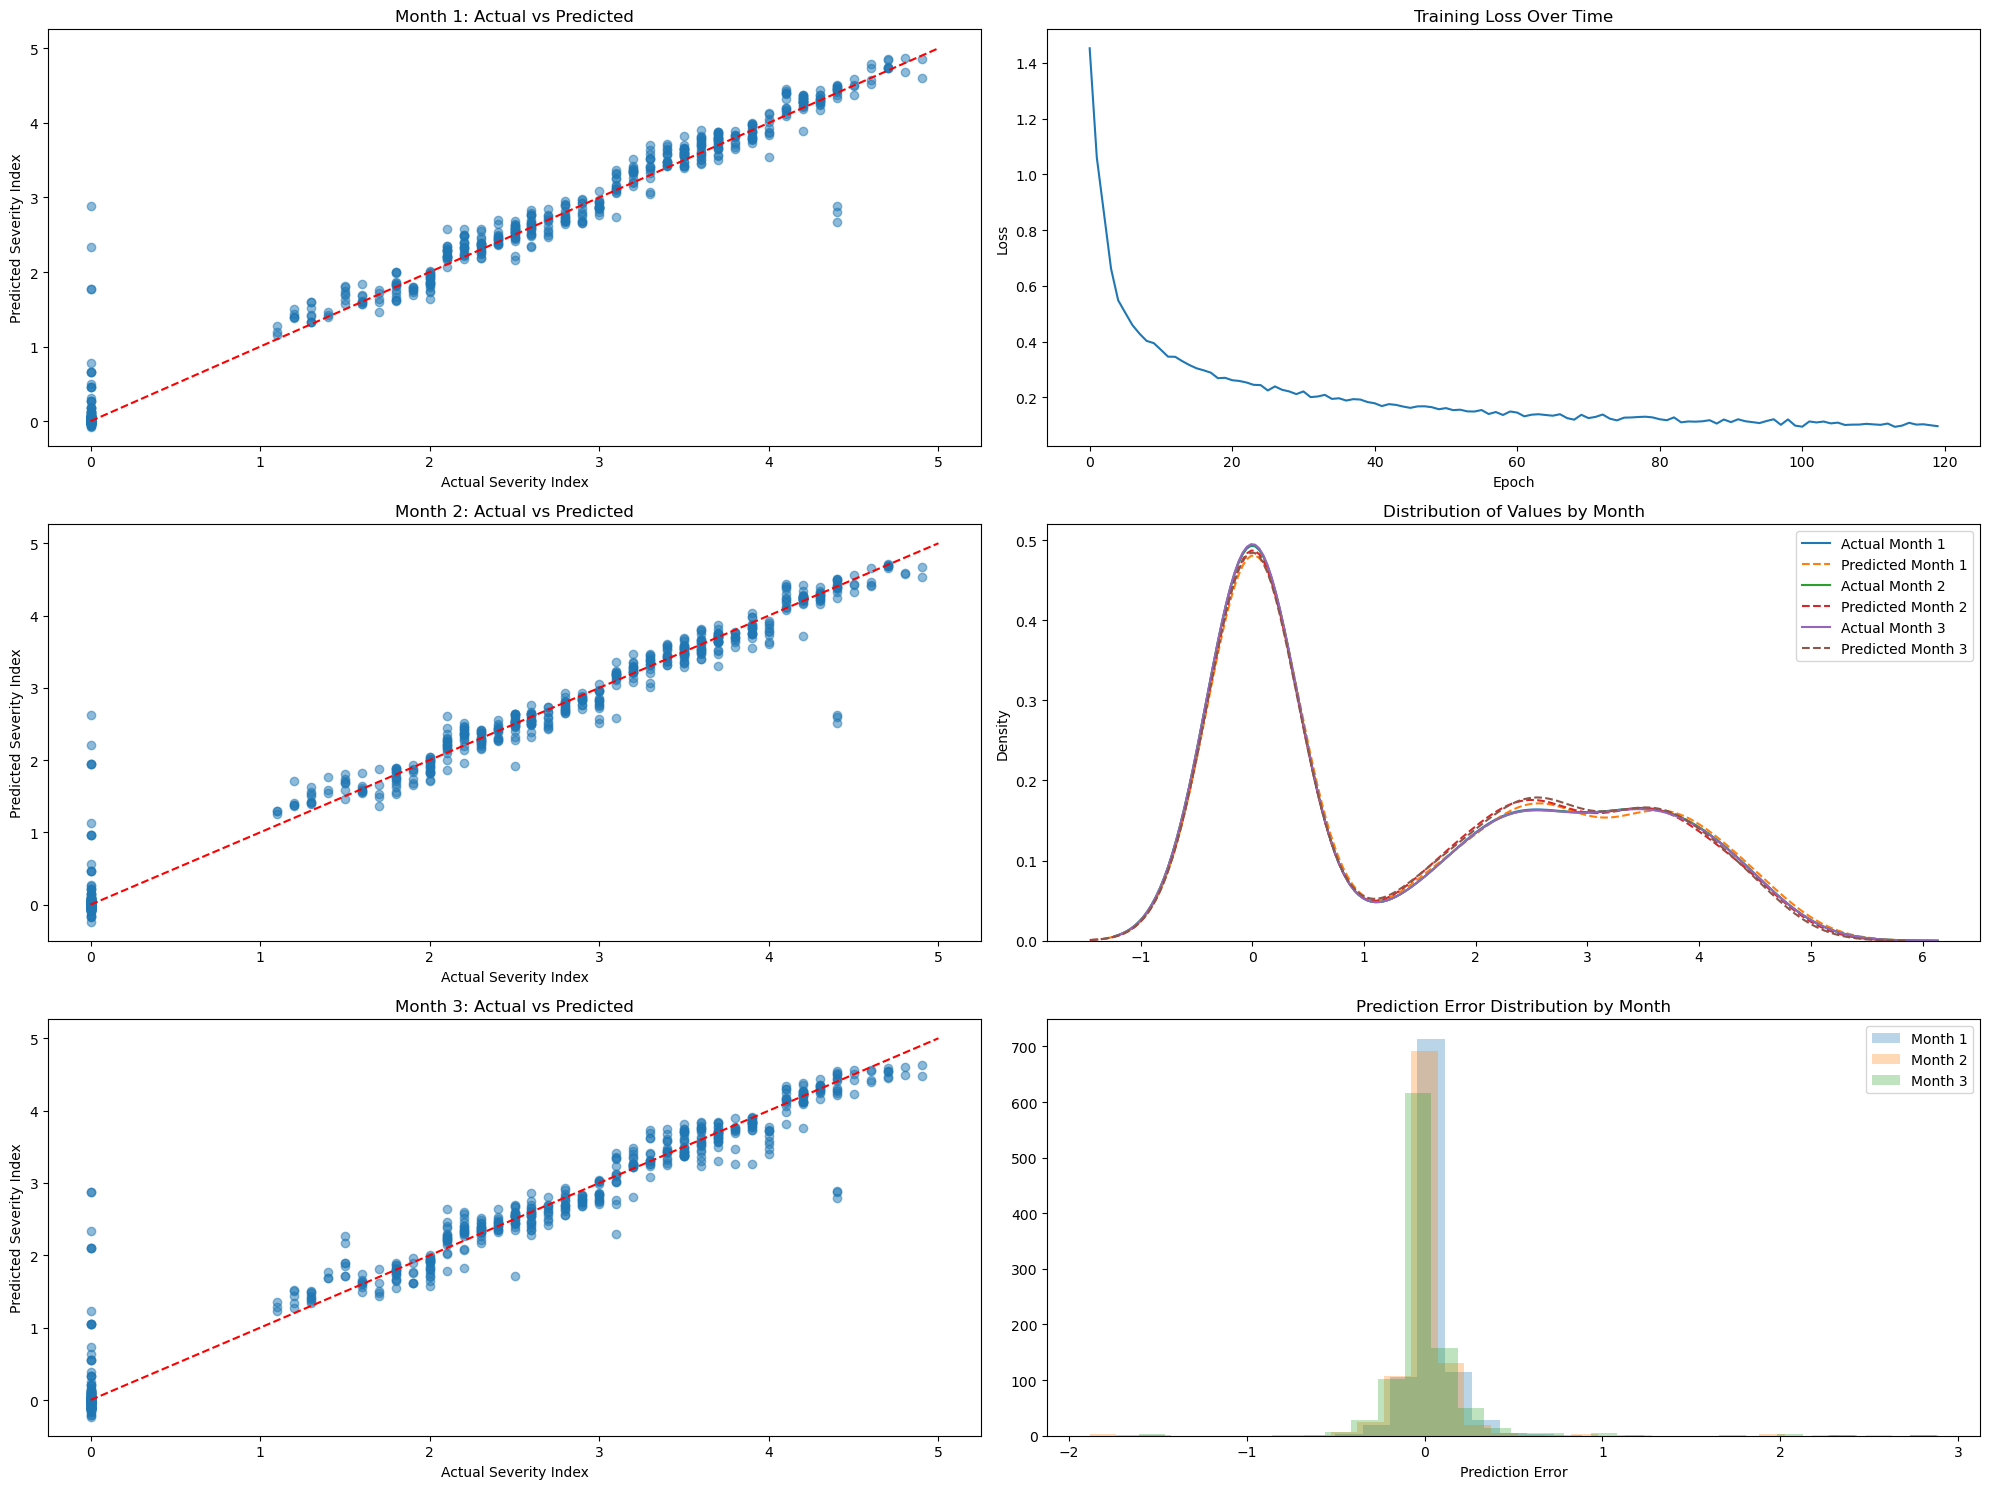


Evaluation and visualization completed successfully!
Visualization outputs saved to: /root/ACAPS/src/task-3-modelling/results/visualizations


In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import torch
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Initialize both evaluator and visualizer
evaluator = ModelEvaluator(config)
visualizer = Visualizer(config)

# Prepare test data and predictions
print("Generating predictions for evaluation...")
test_sequences = X_train[-1000:]  # Using last 1000 sequences
test_targets = y_train[-1000:]

# Get model predictions
trained_model.eval()
with torch.no_grad():
    test_predictions = trained_model(test_sequences)

# Prepare data for evaluation
y_true = test_targets.numpy()
y_pred = test_predictions.numpy()

# Calculate metrics for each month ahead
metrics = {}
for month in range(3):
    month_metrics = {
        'mse': mean_squared_error(y_true[:, month, 0], y_pred[:, month, 0]),
        'rmse': np.sqrt(mean_squared_error(y_true[:, month, 0], y_pred[:, month, 0])),
        'mae': mean_absolute_error(y_true[:, month, 0], y_pred[:, month, 0]),
        'r2': r2_score(y_true[:, month, 0], y_pred[:, month, 0])
    }
    metrics[f'month_{month+1}'] = month_metrics

# Print metrics
print("\nModel Performance Metrics:")
print("-" * 50)
for month, month_metrics in metrics.items():
    print(f"\n{month.upper()}:")
    for metric_name, metric_value in month_metrics.items():
        print(f"{metric_name.upper()}: {metric_value:.4f}")

# Create visualization plots
fig = plt.figure(figsize=(20, 15))

# Plot 1: Actual vs Predicted Values for each month
for month in range(3):
    ax = fig.add_subplot(3, 2, month*2 + 1)
    ax.scatter(y_true[:, month, 0], y_pred[:, month, 0], alpha=0.5)
    ax.plot([0, 5], [0, 5], 'r--')
    ax.set_xlabel('Actual Severity Index')
    ax.set_ylabel('Predicted Severity Index')
    ax.set_title(f'Month {month+1}: Actual vs Predicted')

# Plot 2: Training Loss History
ax = fig.add_subplot(3, 2, 2)
ax.plot(history)
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title('Training Loss Over Time')

# Plot 3: Prediction Distribution for each month
ax = fig.add_subplot(3, 2, 4)
for month in range(3):
    sns.kdeplot(data=y_true[:, month, 0], label=f'Actual Month {month+1}')
    sns.kdeplot(data=y_pred[:, month, 0], label=f'Predicted Month {month+1}', linestyle='--')
ax.set_title('Distribution of Values by Month')
ax.legend()

# Plot 4: Error Distribution for each month
ax = fig.add_subplot(3, 2, 6)
for month in range(3):
    errors = y_pred[:, month, 0] - y_true[:, month, 0]
    ax.hist(errors, bins=30, alpha=0.3, label=f'Month {month+1}')
ax.set_title('Prediction Error Distribution by Month')
ax.set_xlabel('Prediction Error')
ax.legend()

plt.tight_layout()
plt.savefig(str(visualizer.output_path / '3months_crisisseverity_predictor_eval.png'))
plt.show()

print("\nEvaluation and visualization completed successfully!")
print(f"Visualization outputs saved to: {visualizer.output_path}")

# 6. Save Model and Results

In [20]:
import torch
from datetime import datetime

# Create model directory if it doesn't exist
model_dir = config.model_path
model_dir.mkdir(parents=True, exist_ok=True)

# Generate timestamp and model path
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
model_path = model_dir / f"lstm_crisis_severity_predictor_{timestamp}.pt"

# Prepare model state and metadata
model_state = {
    'model_state_dict': trained_model.state_dict(),
    'model_architecture': {
        'input_dim': X_train.shape[2],
        'hidden_dim': config.model_params['lstm']['units'],
        'output_dim': y_train.shape[2],
        'forecast_horizon': 3,
        'n_layers': 2,
        'dropout': config.model_params['lstm']['dropout']
    },
    'feature_names': train_processed['final'].columns[:X_train.shape[2]].tolist(),
    'target_columns': config.targets['severity_level']['columns'],
    'training_history': history,
    'performance_metrics': metrics,
    'training_date': timestamp,
    'sequence_length': 30,
    'scaler': scaler
}

# Save the model
torch.save(model_state, model_path)
print(f"Model saved successfully to: {model_path}")


Model saved successfully to: /root/ACAPS/src/task-3-modelling/models/lstm_crisis_severity_predictor_20241116_092126.pt
